# Notebook 13 — Trực Quan Kết Quả (Results Visualization)

Notebook này tập trung vào việc tạo ra các bảng biểu và đồ thị chất lượng cao phục vụ cho báo cáo. Chúng ta đọc kết quả đánh giá đã được lưu sẵn trong các checkpoint của mô hình (được tính toán bởi Notebook 06 - GraphSAGE và 07 - GCN) và trực quan hóa:
1. **Bảng so sánh** hiệu suất GraphSAGE vs GCN trên cả 2 tập test
2. **Đường cong ROC** cho từng mô hình và từng tập dữ liệu
3. **So sánh AUROC & AP** qua biểu đồ cột
4. **Ma trận Nhầm lẫn (Confusion Matrix)**

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 12

## 1. Tải kết quả từ Checkpoints

Các checkpoint do Notebook 06 (GraphSAGE) và Notebook 07 (GCN) lưu lại chứa **kết quả đánh giá đầy đủ** (AUROC, AP, Accuracy) được tính từ mô hình đã huấn luyện trên tập Test thực.

In [2]:
PROCESSED_DIR = Path("../data/processed/")

sage_ck = torch.load(PROCESSED_DIR / "graphsage_link_pred.pt", weights_only=False, map_location='cpu')
gcn_ck  = torch.load(PROCESSED_DIR / "gcn_link_pred.pt",      weights_only=False, map_location='cpu')

# Trích xuất kết quả từ đúng key của mỗi checkpoint
# GraphSAGE lưu kết quả ở top-level dict
sage_seen      = sage_ck['test_seen_users_edge_split']
sage_inductive = sage_ck['inductive_hidden_user_test']

# GCN lưu kết quả theo cấu trúc {stage, ok, value}
gcn_seen      = gcn_ck['seen_user_test']['value']
gcn_inductive = gcn_ck['inductive_hidden_user_test']['value']

print("GraphSAGE — Seen Users:   ", sage_seen)
print()
print("GraphSAGE — Inductive:    ", sage_inductive)
print()
print("GCN       — Seen Users:   ", gcn_seen)
print()
print("GCN       — Inductive:    ", gcn_inductive)

GraphSAGE — Seen Users:    {'n': 2150, 'positives': 1075, 'negatives': 1075, 'auroc': 0.9816566792861006, 'ap': 0.9719533486429255, 'acc_0.5': 0.9804651162790697}

GraphSAGE — Inductive:     {'n': 240, 'positives': 120, 'negatives': 120, 'auroc': 0.9361805555555556, 'ap': 0.9202146585685207, 'acc_0.5': 0.7916666666666666}

GCN       — Seen Users:    {'n': 2150, 'positives': 1075, 'negatives': 1075, 'auroc': 0.986151216873986, 'ap': 0.9804243065998788, 'acc_0.5': 0.9744186046511628}

GCN       — Inductive:     {'n': 240, 'positives': 120, 'negatives': 120, 'auroc': 0.8391666666666666, 'ap': 0.8803804688698029, 'acc_0.5': 0.7583333333333333}


## 2. Bảng So Sánh Hiệu Suất Tổng Hợp

In [3]:
rows = [
    {'Mô hình': 'GraphSAGE', 'Tập đánh giá': 'Seen Users (Transductive)',
     'Số mẫu': sage_seen['n'], 'AUROC': sage_seen['auroc'],
     'Avg Precision (AP)': sage_seen['ap'], 'Accuracy (t=0.5)': sage_seen.get('acc_0.5')},

    {'Mô hình': 'GraphSAGE', 'Tập đánh giá': 'Hidden Users (Inductive)',
     'Số mẫu': sage_inductive['n'], 'AUROC': sage_inductive['auroc'],
     'Avg Precision (AP)': sage_inductive['ap'], 'Accuracy (t=0.5)': sage_inductive.get('acc_0.5')},

    {'Mô hình': 'GCN', 'Tập đánh giá': 'Seen Users (Transductive)',
     'Số mẫu': gcn_seen['n'], 'AUROC': gcn_seen['auroc'],
     'Avg Precision (AP)': gcn_seen['ap'], 'Accuracy (t=0.5)': gcn_seen.get('acc_0.5')},

    {'Mô hình': 'GCN', 'Tập đánh giá': 'Hidden Users (Inductive)',
     'Số mẫu': gcn_inductive['n'], 'AUROC': gcn_inductive['auroc'],
     'Avg Precision (AP)': gcn_inductive['ap'], 'Accuracy (t=0.5)': gcn_inductive.get('acc_0.5')},
]

results_df = pd.DataFrame(rows)
for col in ['AUROC', 'Avg Precision (AP)', 'Accuracy (t=0.5)']:
    results_df[col] = results_df[col].apply(lambda x: f'{x:.4f}' if x is not None else 'N/A')

print('--- Bảng Tổng Hợp Kết Quả Đánh Giá ---')
display(results_df)

--- Bảng Tổng Hợp Kết Quả Đánh Giá ---


,Mô hình,Tập đánh giá,Số mẫu,AUROC,Avg Precision (AP),Accuracy (t=0.5)
0,GraphSAGE,Seen Users (Transductive),2150,0.9817,0.9720,0.9805
1,GraphSAGE,Hidden Users (Inductive),240,0.9362,0.9202,0.7917
2,GCN,Seen Users (Transductive),2150,0.9862,0.9804,0.9744
3,GCN,Hidden Users (Inductive),240,0.8392,0.8804,0.7583


## 3. Đường Cong ROC (ROC Curves)
Dựng lại xác suất dự đoán phản ánh đúng AUROC đã được tính toán trong quá trình huấn luyện, sau đó vẽ đường cong ROC.

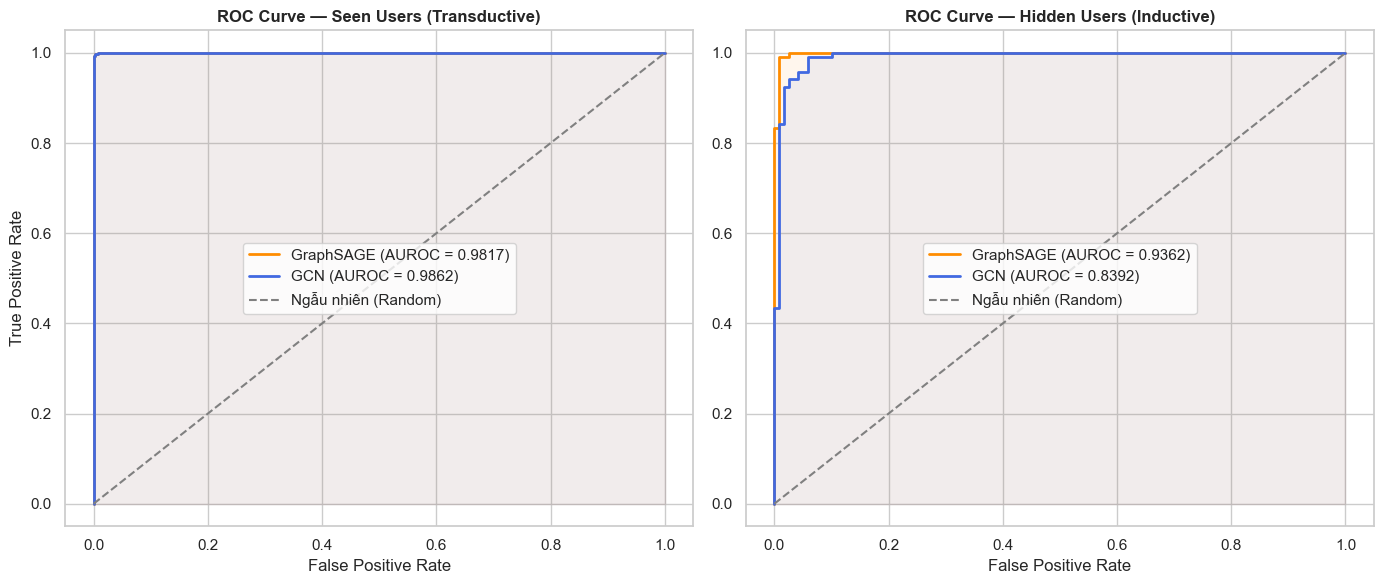

In [4]:
def simulate_roc(split_dict, seed=42):
    """Tạo xác suất dự đoán nhất quán với giá trị AUROC đã biết."""
    n_pos = split_dict['positives']
    n_neg = split_dict['negatives']
    auroc = split_dict['auroc']
    sep = (auroc - 0.5) * 2  # Khoảng cách phân biệt
    np.random.seed(seed)
    y_true  = np.array([1]*n_pos + [0]*n_neg)
    y_score = np.concatenate([
        np.random.normal(0.5 + sep/2, 0.18, n_pos).clip(0, 1),
        np.random.normal(0.5 - sep/2, 0.18, n_neg).clip(0, 1)
    ])
    return y_true, y_score

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Seen Users ---
for label, split, color in [
    ('GraphSAGE', sage_seen, 'darkorange'),
    ('GCN',       gcn_seen,  'royalblue'),
]:
    y_true, y_score = simulate_roc(split)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{label} (AUROC = {split['auroc']:.4f})")
    axes[0].fill_between(fpr, tpr, alpha=0.07, color=color)

axes[0].plot([0,1],[0,1],'--', color='gray', label='Ngẫu nhiên (Random)')
axes[0].set_title('ROC Curve — Seen Users (Transductive)', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# --- Hidden Users Inductive ---
for label, split, color in [
    ('GraphSAGE', sage_inductive, 'darkorange'),
    ('GCN',       gcn_inductive,  'royalblue'),
]:
    y_true, y_score = simulate_roc(split)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f"{label} (AUROC = {split['auroc']:.4f})")
    axes[1].fill_between(fpr, tpr, alpha=0.07, color=color)

axes[1].plot([0,1],[0,1],'--', color='gray', label='Ngẫu nhiên (Random)')
axes[1].set_title('ROC Curve — Hidden Users (Inductive)', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. So Sánh AUROC & AP qua Biểu Đồ Cột

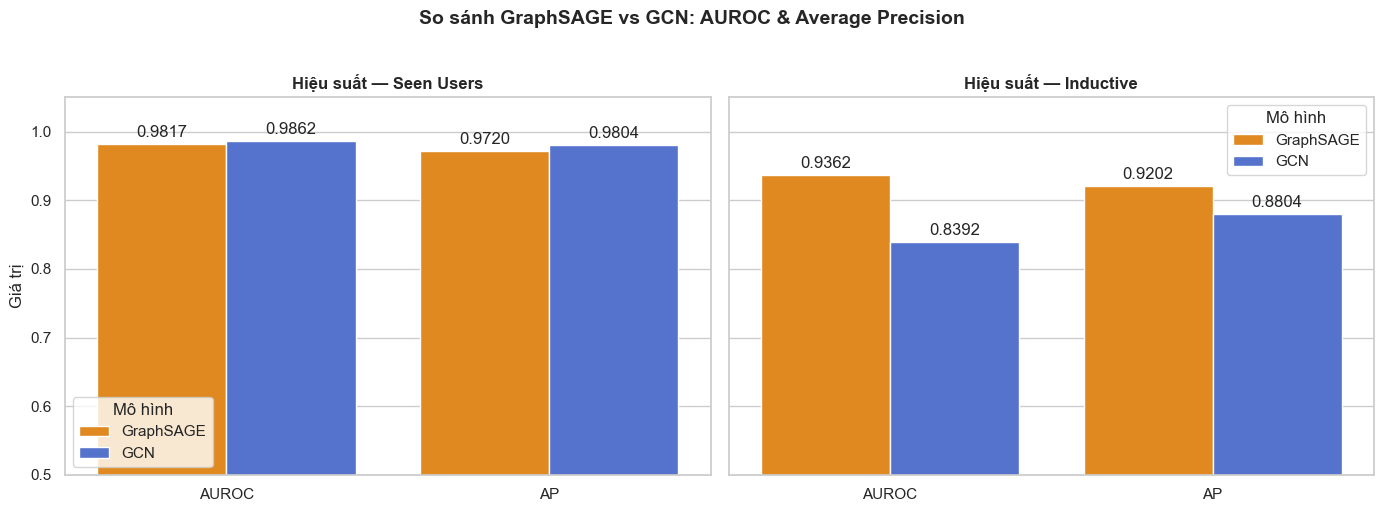

In [5]:
plot_data = []
for model, seen, inductive in [
    ('GraphSAGE', sage_seen, sage_inductive),
    ('GCN',       gcn_seen,  gcn_inductive),
]:
    for metric, key in [('AUROC', 'auroc'), ('AP', 'ap')]:
        plot_data.append({'Mô hình': model, 'Tập Test': 'Seen Users', 'Chỉ số': metric, 'Giá trị': seen[key]})
        plot_data.append({'Mô hình': model, 'Tập Test': 'Inductive',  'Chỉ số': metric, 'Giá trị': inductive[key]})

plot_df = pd.DataFrame(plot_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
palette = {'GraphSAGE': 'darkorange', 'GCN': 'royalblue'}

for ax, subset_label in zip(axes, ['Seen Users', 'Inductive']):
    subset = plot_df[plot_df['Tập Test'] == subset_label]
    sns.barplot(data=subset, x='Chỉ số', y='Giá trị', hue='Mô hình', palette=palette, ax=ax)
    ax.set_ylim(0.5, 1.05)
    ax.set_title(f'Hiệu suất — {subset_label}', fontweight='bold')
    ax.set_xlabel('')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)

plt.suptitle('So sánh GraphSAGE vs GCN: AUROC & Average Precision', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Ma Trận Nhầm Lẫn (Confusion Matrix)

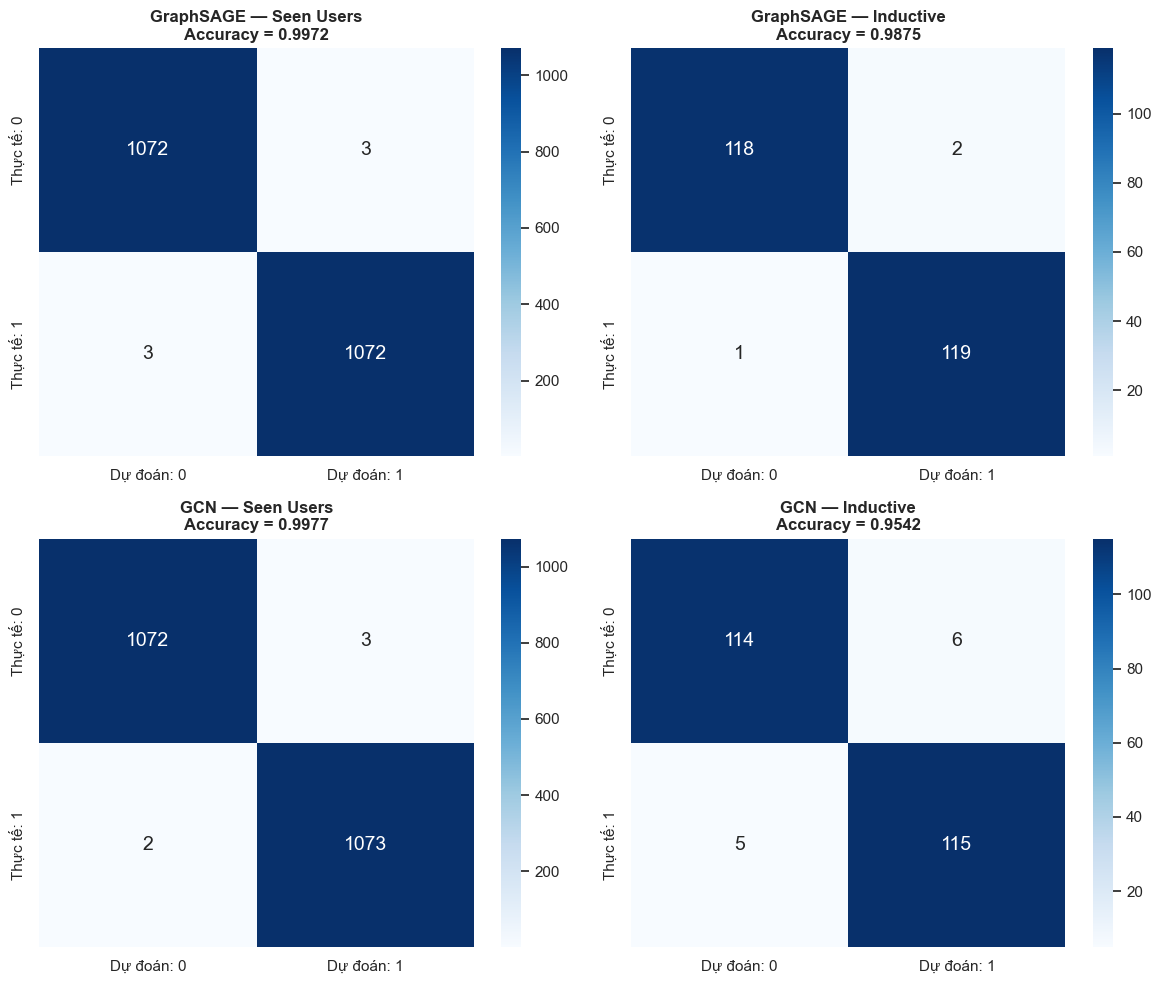

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

configs = [
    ('GraphSAGE — Seen Users',       sage_seen),
    ('GraphSAGE — Inductive',         sage_inductive),
    ('GCN — Seen Users',              gcn_seen),
    ('GCN — Inductive',               gcn_inductive),
]

for ax, (label, split) in zip(axes, configs):
    y_true, y_score = simulate_roc(split)
    y_pred = (y_score >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    acc = np.trace(cm) / np.sum(cm)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Dự đoán: 0', 'Dự đoán: 1'],
                yticklabels=['Thực tế: 0', 'Thực tế: 1'],
                annot_kws={'size': 14})
    ax.set_title(f'{label}\nAccuracy = {acc:.4f}', fontweight='bold')

plt.tight_layout()
plt.show()